In [1]:
import numpy as np
import cv2
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import gzip
import pickle
import os
import matplotlib.pyplot as plt

In [2]:
import cv2
import numpy as np

def extract_features(loaded_data):
    raw_stats = {} 

    for frame_idx, data in loaded_data.items():
        masks = data["out_binary_masks"]
        obj_ids = data["out_obj_ids"]
        
        for i, obj_id in enumerate(obj_ids):
            mask = masks[i]
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours: continue
            
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            if area < 50: continue 
            
            epsilon = 0.005 * cv2.arcLength(cnt, True)
            cnt = cv2.approxPolyDP(cnt, epsilon, True)

            # calculate Convexity Defects / identation
            defect_count = 0
            try:
                hull_indices = cv2.convexHull(cnt, returnPoints=False)
                if hull_indices is not None and len(hull_indices) > 3:
                    defects = cv2.convexityDefects(cnt, hull_indices)
                    if defects is not None:
                        for j in range(defects.shape[0]):
                            depth = defects[j, 0, 3] / 256.0
                            if depth > 5: defect_count += 1
            except cv2.error:
                pass

            # get position with cv2 moments (see doc)
            M = cv2.moments(cnt)
            if M['m00'] == 0: continue
            pos = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00']))

            if obj_id not in raw_stats:
                raw_stats[obj_id] = {'areas': [], 'positions': [], 'defects': []}
            
            raw_stats[obj_id]['areas'].append(area)
            raw_stats[obj_id]['positions'].append(pos)
            raw_stats[obj_id]['defects'].append(defect_count)

    results_dict = {}
    temp_displacements = {}

    for obj_id, d in raw_stats.items():
        areas = np.array(d['areas'])
        positions = np.array(d['positions'])
        defects = sorted(d['defects'])
        
        # A) movement features
        if len(positions) > 1:
            diffs = np.diff(positions, axis=0)
            velocities = np.linalg.norm(diffs, axis=1)
            mean_v, max_v = np.mean(velocities), np.max(velocities)
            speed_delta = max_v - np.min(velocities)
            
            # Max Path 
            dist_matrix_diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
            max_path_dist = np.max(np.sqrt(np.sum(dist_matrix_diff**2, axis=-1)))
        else:
            mean_v, max_v, speed_delta, max_path_dist = 0.0, 0.0, 0.0, 0.0

        # B) morphological features
        avg_area = np.mean(areas)
        std_area = np.std(areas)
        rel_area_delta = (np.max(areas) - np.min(areas)) / avg_area if avg_area > 0 else 0
        
        # use top 30% of defects only since there can be many frames that are "advantageous" for fish e.g. side view + tail is hidden
        n_best = max(1, int(len(defects) * 0.3))
        representative_defects = np.median(defects[:n_best])

        # C) get relative features (some vary with object size which is false!!)
        obj_diameter = np.sqrt(avg_area)
        rel_disp = max_path_dist / obj_diameter if obj_diameter > 0 else 0
        temp_displacements[obj_id] = rel_disp

        # save results
        results_dict[obj_id] = [
            avg_area,               # 0
            std_area,               # 1
            representative_defects, # 2
            mean_v,                 # 3
            max_v,                  # 4
            rel_area_delta,         # 5
            speed_delta,            # 6
            max_path_dist           # 7
        ]

    # --- normalization across all objects ---
    if temp_displacements:
        vals = list(temp_displacements.values())
        v_min, v_max = min(vals), max(vals)
        v_range = v_max - v_min if v_max > v_min else 1.0
        
        for obj_id in results_dict:
            norm_disp = (temp_displacements[obj_id] - v_min) / v_range
            results_dict[obj_id].append(norm_disp) # Jetzt Index 8

    return results_dict

In [3]:
#anderes clustering verwenden statt kmeans
# glätten über die zeit

In [4]:
file_path = "./outputs_raw_masks_compressed/tracking_results_video_006_0001_to_0040.pkl.gz"

if not os.path.exists(file_path):
    print(f"Datei nicht gefunden: {file_path}")
else:
    print(f"Lade und entpacke {file_path}...")
    with gzip.open(file_path, "rb") as f:
        loaded_data = pickle.load(f)
    results = extract_features(loaded_data)
    obj_ids = list(results.keys())
    X = np.array(list(results.values()))

Lade und entpacke ./outputs_raw_masks_compressed/tracking_results_video_006_0001_to_0040.pkl.gz...


In [5]:
loaded_data.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39])

In [6]:
loaded_data[0].keys()

dict_keys(['out_obj_ids', 'out_binary_masks'])

In [7]:
def plot_snails_vs_fish(loaded_data, snail_ids, start_frame=0, step=10):
    all_indices = sorted(loaded_data.keys())
    sampled_indices = [i for i in all_indices if i >= start_frame and i % step == 0]
    
    n_frames = len(sampled_indices)
    if n_frames == 0:
        print("Keine Frames zum Plotten gefunden.")
        return

    fig, axes = plt.subplots(n_frames, 1, figsize=(15, 8 * n_frames))
    if n_frames == 1: axes = [axes]

    for ax, f_idx in zip(axes, sampled_indices):
        masks = loaded_data[f_idx]['out_binary_masks']
        obj_ids = loaded_data[f_idx]['out_obj_ids']
        
        h, w = masks.shape[1], masks.shape[2]
        rgb_output = np.zeros((h, w, 3), dtype=np.uint8)
        
        for i, obj_id in enumerate(obj_ids):
            mask = masks[i].astype(np.uint8)
            
            if obj_id in snail_ids:
                color = [255, 0, 0]    # Rot
            else:
                color = [0, 150, 255]  # Blau/Cyan
            
            rgb_output[mask > 0] = color
            
            M = cv2.moments(mask)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
                # Text-Konfiguration
                text = str(obj_id)
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 1.3
                
                cv2.putText(rgb_output, text, (cx, cy), font, font_scale, (0, 0, 0), 6, cv2.LINE_AA)
                cv2.putText(rgb_output, text, (cx, cy), font, font_scale, (255, 255, 255), 2, cv2.LINE_AA)
        
        ax.imshow(rgb_output)
        ax.set_title(f"Frame {f_idx} | ROT: Schnecken | BLAU: Fische", fontsize=16, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
def plot_sampled_masks(loaded_data, start_frame=0, step=5):
    all_indices = sorted(loaded_data.keys())
    sampled_indices = [i for i in all_indices if i >= start_frame and i % step == 0]
    
    n_frames = len(sampled_indices)
    if n_frames == 0:
        print("Keine Frames zum Plotten gefunden.")
        return

    fig, axes = plt.subplots(n_frames, 1, figsize=(12, 6 * n_frames))
    
    if n_frames == 1:
        axes = [axes]

    for ax, f_idx in zip(axes, sampled_indices):
        masks = loaded_data[f_idx]['out_binary_masks'] # Shape: (N, 1080, 1920)

        combined_mask = np.max(masks, axis=0)
        
        ax.imshow(combined_mask, cmap='gray')
        ax.set_title(f"Frame {f_idx} - Anzahl Objekte: {masks.shape[0]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

#plot_sampled_masks(loaded_data, start_frame=0, step=5)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

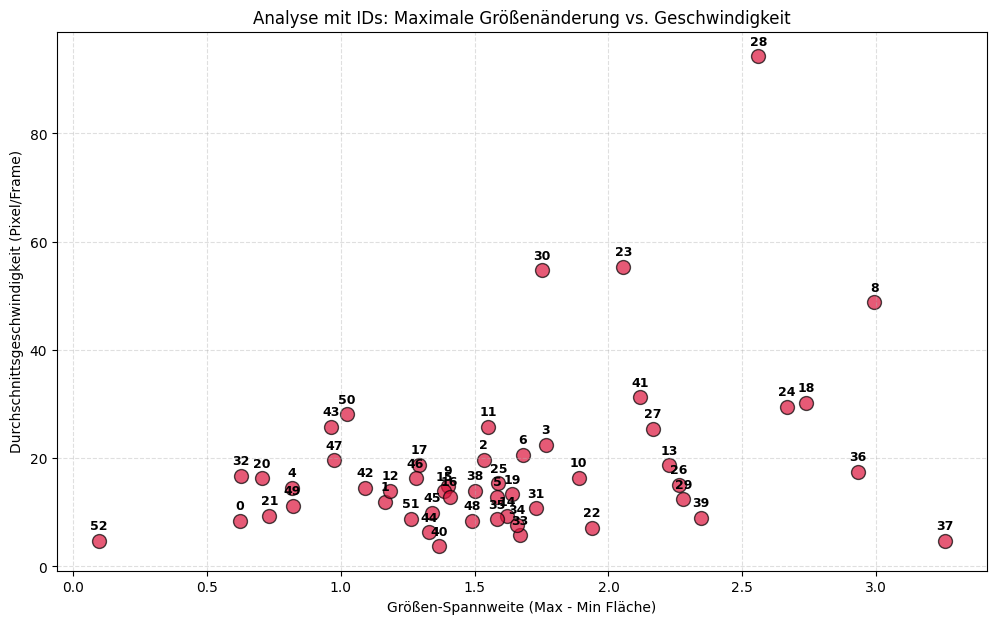

In [10]:
results = extract_features(loaded_data)
obj_ids = list(results.keys())  
X = np.array(list(results.values()))

plt.figure(figsize=(12, 7))

plt.scatter(X[:, 5], X[:, 3], color='crimson', alpha=0.7, s=100, edgecolors='black')

for i, txt in enumerate(obj_ids):
    plt.annotate(
        txt, 
        (X[i, 5], X[i, 3]), 
        textcoords="offset points", 
        xytext=(0, 8),               
        ha='center',                 
        fontsize=9, 
        fontweight='bold',
        color='black'
    )

plt.xlabel("Größen-Spannweite (Max - Min Fläche)")
plt.ylabel("Durchschnittsgeschwindigkeit (Pixel/Frame)")
plt.title("Analyse mit IDs: Maximale Größenänderung vs. Geschwindigkeit")
plt.grid(True, linestyle='--', alpha=0.4)

#plt.show()

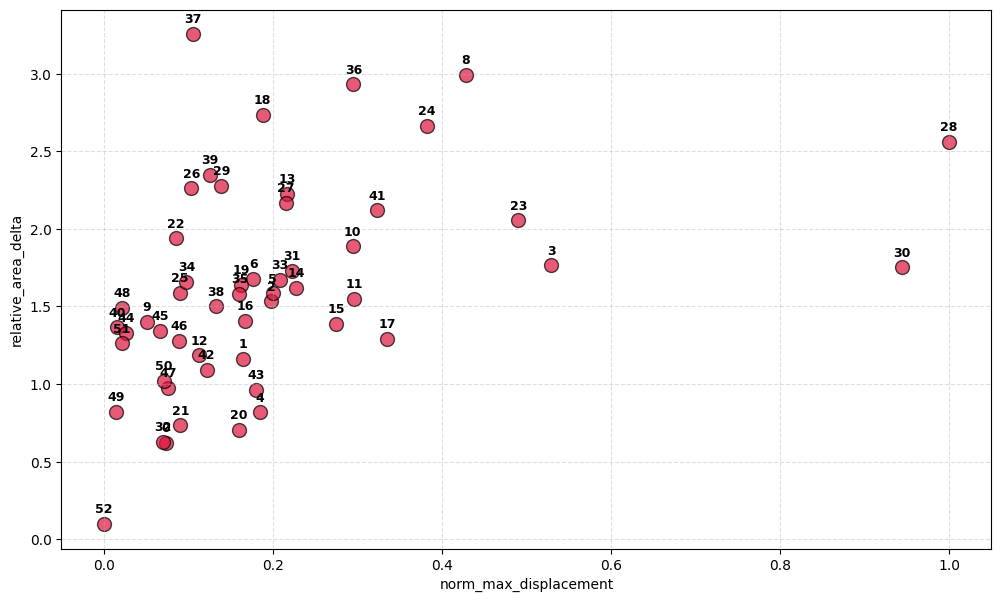

In [11]:
results = extract_features(loaded_data)
obj_ids = list(results.keys())  # Die IDs als Liste holen
X = np.array(list(results.values()))

plt.figure(figsize=(12, 7))

plt.scatter(X[:, 8], X[:, 5], color='crimson', alpha=0.7, s=100, edgecolors='black')

for i, txt in enumerate(obj_ids):
    plt.annotate(
        txt, 
        (X[i, 8], X[i, 5]), 
        textcoords="offset points", 
        xytext=(0, 8),               
        ha='center',                 
        fontsize=9, 
        fontweight='bold',
        color='black'
    )

plt.xlabel("norm_max_displacement")
plt.ylabel("relative_area_delta")
plt.grid(True, linestyle='--', alpha=0.4)

#plt.show()

## Weitere Clustering Methoden

### GMM with area_delta only

In [12]:
total_frames = len(loaded_data)
occurrence_counts = {}
for frame_idx in loaded_data:
    for obj_id in loaded_data[frame_idx]['out_obj_ids']:
        occurrence_counts[obj_id] = occurrence_counts.get(obj_id, 0) + 1

In [13]:
from sklearn.mixture import GaussianMixture
import numpy as np



stable_indices = []
short_lived_ids = []

for i, obj_id in enumerate(obj_ids):
    persistence = occurrence_counts[obj_id] / total_frames
    if persistence >= 0.5:
        stable_indices.append(i)
    else:
        short_lived_ids.append(obj_id)


X_stable_scaled = X_scaled[stable_indices]
X_stable_raw = X[stable_indices] 
stable_obj_ids = [obj_ids[i] for i in stable_indices]

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
clusters_stable = gmm.fit_predict(X_stable_scaled)

area_delta_c0 = np.mean(X_stable_raw[clusters_stable == 0, 5])
area_delta_c1 = np.mean(X_stable_raw[clusters_stable == 1, 5])

snail_cluster = 0 if area_delta_c0 < area_delta_c1 else 1

snail_ids2 = []
fish_ids2 = list(short_lived_ids) 

for i, cluster in enumerate(clusters_stable):
    if cluster == snail_cluster:
        snail_ids2.append(stable_obj_ids[i])
    else:
        fish_ids2.append(stable_obj_ids[i])

print(f"Filterung abgeschlossen:")
print(f"- {len(short_lived_ids)} Objekte wegen kurzer Lebensdauer (< 50%) ignoriert (direkt Fisch).")
print(f"- {len(stable_obj_ids)} Objekte für GMM-Clustering verwendet.")
print(f"--- Finale Zählung: {len(snail_ids2)} Schnecken, {len(fish_ids2)} Fische.")

Filterung abgeschlossen:
- 14 Objekte wegen kurzer Lebensdauer (< 50%) ignoriert (direkt Fisch).
- 38 Objekte für GMM-Clustering verwendet.
--- Finale Zählung: 18 Schnecken, 34 Fische.


In [14]:
#plot_snails_vs_fish(loaded_data, snail_ids2, step=2)

In [15]:
from sklearn.cluster import HDBSCAN
import numpy as np

total_frames = len(loaded_data)
stable_indices = [i for i, oid in enumerate(obj_ids) 
                  if (occurrence_counts[oid] / total_frames) >= 0.5]

if not stable_indices:
    print("Keine stabilen Objekte gefunden.")
    snail_ids = []
    rest_ids = list(obj_ids)
else:
    stable_obj_ids = [obj_ids[i] for i in stable_indices]
    
    X_subset = X_scaled[stable_indices][:, [5, 8]]


    model = HDBSCAN(min_cluster_size=2, min_samples=1)
    clusters = model.fit_predict(X_subset)

    snail_ids = []
    rest_ids = [oid for i, oid in enumerate(obj_ids) if i not in stable_indices]

    unique_clusters = [c for c in np.unique(clusters) if c != -1]

    for c in unique_clusters:
        m = np.mean(X_subset[clusters == c], axis=0)
        

        score = m[0] + m[1] 
        
        if score < 0: 
            c_member_ids = [stable_obj_ids[i] for i, cl in enumerate(clusters) if cl == c]
            snail_ids.extend(c_member_ids)
        else:
            c_member_ids = [stable_obj_ids[i] for i, cl in enumerate(clusters) if cl == c]
            rest_ids.extend(c_member_ids)

    noise_ids = [stable_obj_ids[i] for i, cl in enumerate(clusters) if cl == -1]
    rest_ids.extend(noise_ids)

print(f"HDBSCAN Analyse (Features 5 & 8) beendet.")
print(f"- {len(snail_ids)} Schnecken-IDs (dichte, stabile Kerne)")
print(f"- {len(rest_ids)} Rest-IDs (Rauschen, Fische, Kurzlebige)")

HDBSCAN Analyse (Features 5 & 8) beendet.
- 12 Schnecken-IDs (dichte, stabile Kerne)
- 40 Rest-IDs (Rauschen, Fische, Kurzlebige)


/home/xxbananaopxx/anaconda3/envs/ma1/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


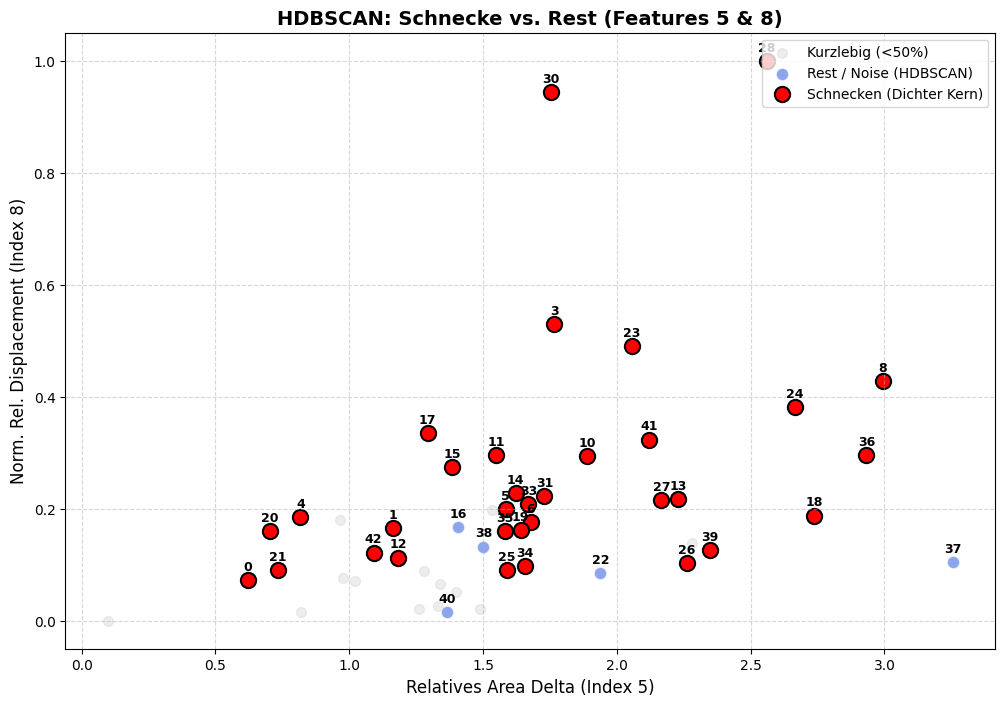

In [16]:
import matplotlib.pyplot as plt
import numpy as np


short_lived_indices = [i for i in range(len(obj_ids)) if i not in stable_indices]

X_stable_raw = X[stable_indices]

plt.figure(figsize=(12, 8))

if len(short_lived_indices) > 0:
    plt.scatter(X[short_lived_indices, 5], X[short_lived_indices, 8], 
                c='lightgrey', label='Kurzlebig (<50%)', s=50, alpha=0.4)


noise_mask = (clusters == -1)
if np.any(noise_mask):
    plt.scatter(X_stable_raw[noise_mask, 5], X_stable_raw[noise_mask, 8], 
                c='royalblue', label='Rest / Noise (HDBSCAN)', s=80, alpha=0.6, edgecolors='white')

# 3. Kategorie: Schnecken-Cluster (Der dichte Kern)
snail_mask = (clusters != -1)
if np.any(snail_mask):
    plt.scatter(X_stable_raw[snail_mask, 5], X_stable_raw[snail_mask, 8], 
                c='red', label='Schnecken (Dichter Kern)', s=120, edgecolors='black', linewidth=1.5)

# 4. IDs als Text hinzufügen (nur für stabile Objekte)
for i, obj_id in enumerate(stable_obj_ids):
    plt.annotate(obj_id, 
                 (X_stable_raw[i, 5], X_stable_raw[i, 8]),
                 xytext=(0, 7), textcoords="offset points", 
                 ha='center', fontsize=9, fontweight='bold')

plt.xlabel("Relatives Area Delta (Index 5)", fontsize=12)
plt.ylabel("Norm. Rel. Displacement (Index 8)", fontsize=12)
plt.title("HDBSCAN: Schnecke vs. Rest (Features 5 & 8)", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.show()

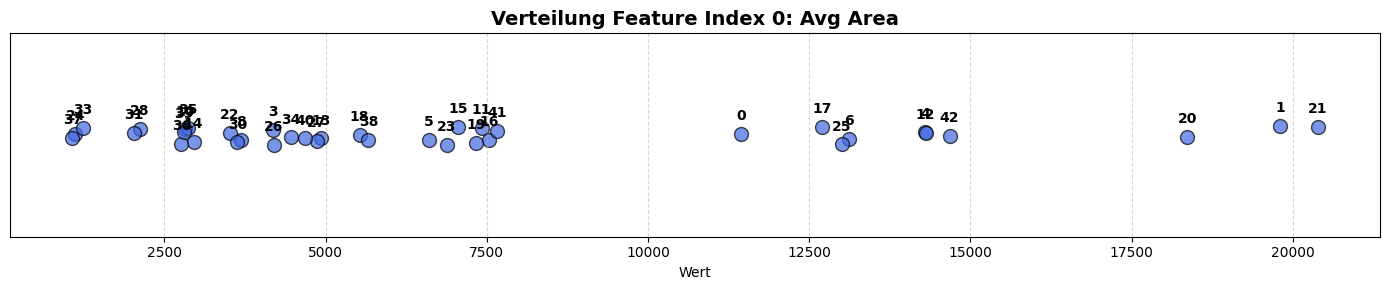

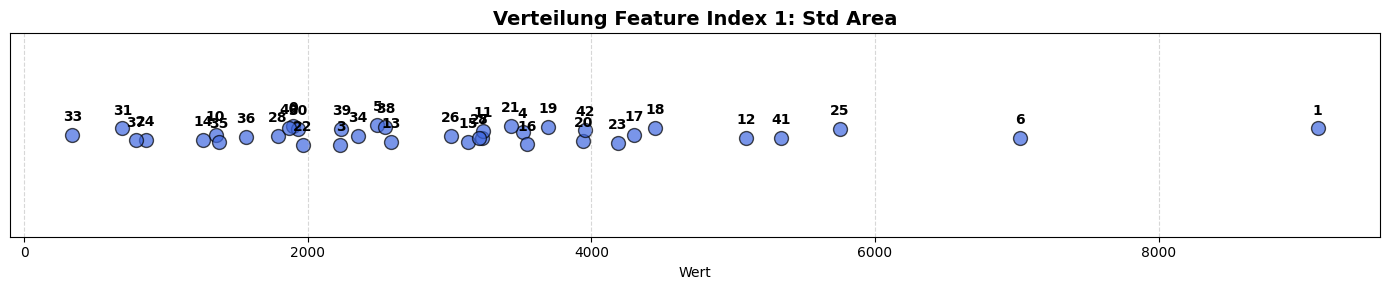


WERTE FÜR Index 2: Circularity / Solidity / Defects
ID   3 : 0.0000
ID   8 : 0.0000
ID  10 : 0.0000
ID  13 : 0.0000
ID  14 : 0.0000
ID  22 : 0.0000
ID  24 : 0.0000
ID  26 : 0.0000
ID  28 : 0.0000
ID  30 : 0.0000
ID  31 : 0.0000
ID  33 : 0.0000
ID  34 : 0.0000
ID  35 : 0.0000
ID  36 : 0.0000
ID  37 : 0.0000
ID  38 : 0.0000
ID  39 : 0.0000
ID  40 : 0.0000
ID  41 : 0.0000
ID  42 : 0.0000
ID  18 : 0.5000
ID  23 : 0.5000
ID  27 : 0.5000
ID   5 : 1.0000
ID  11 : 1.0000
ID  16 : 1.0000
ID  19 : 1.0000
ID  25 : 1.0000
ID   1 : 2.0000
ID   6 : 2.0000
ID  12 : 2.0000
ID  15 : 2.0000
ID  17 : 2.0000
ID   0 : 3.0000
ID   4 : 3.0000
ID  20 : 3.0000
ID  21 : 3.5000



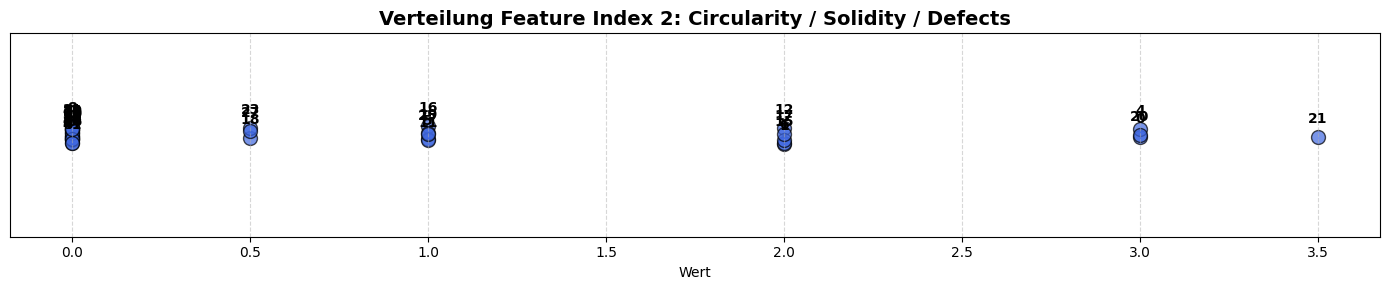

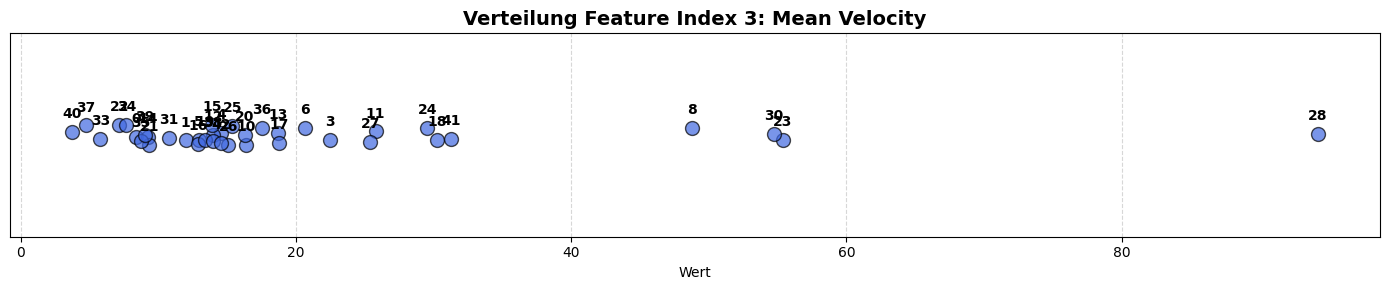

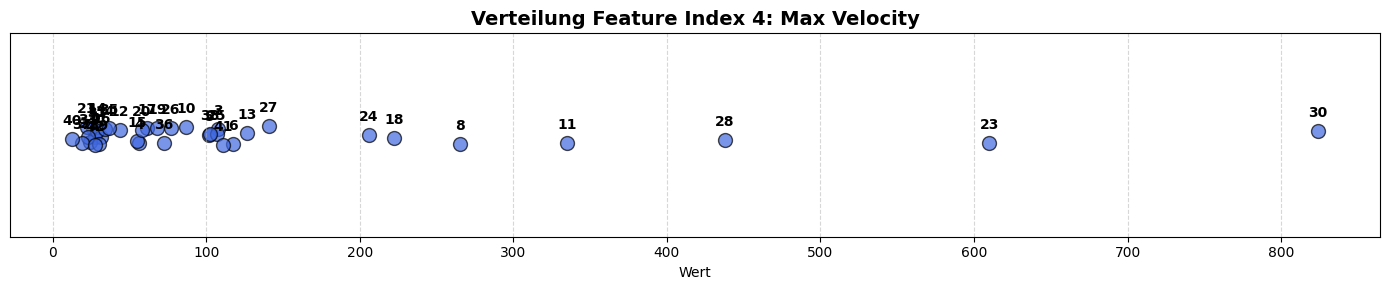

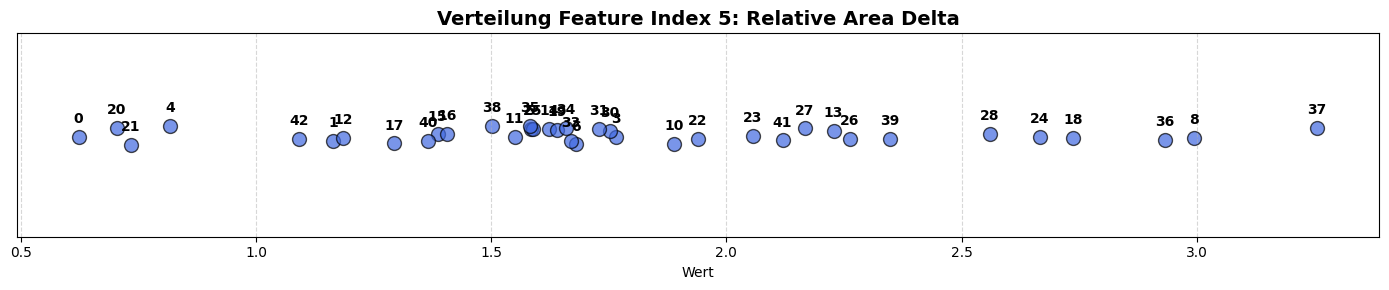

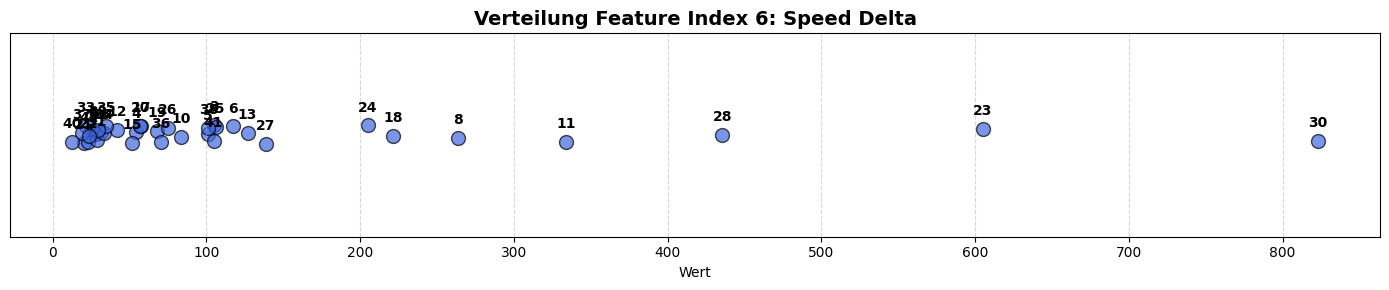

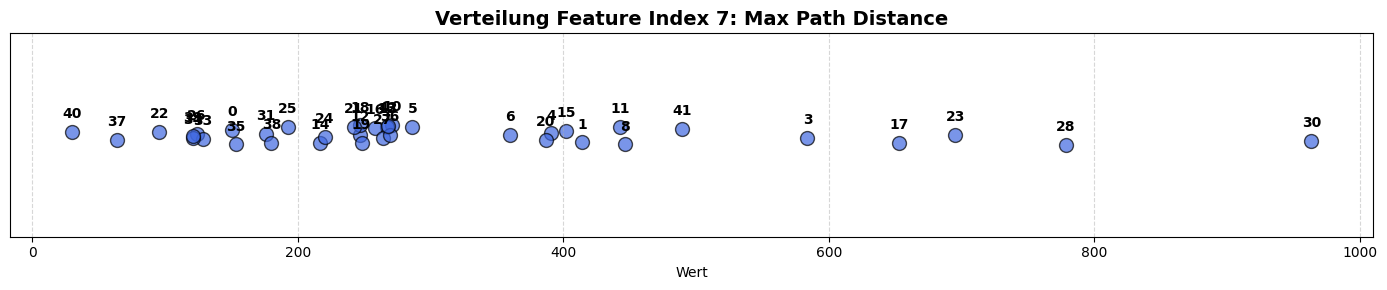

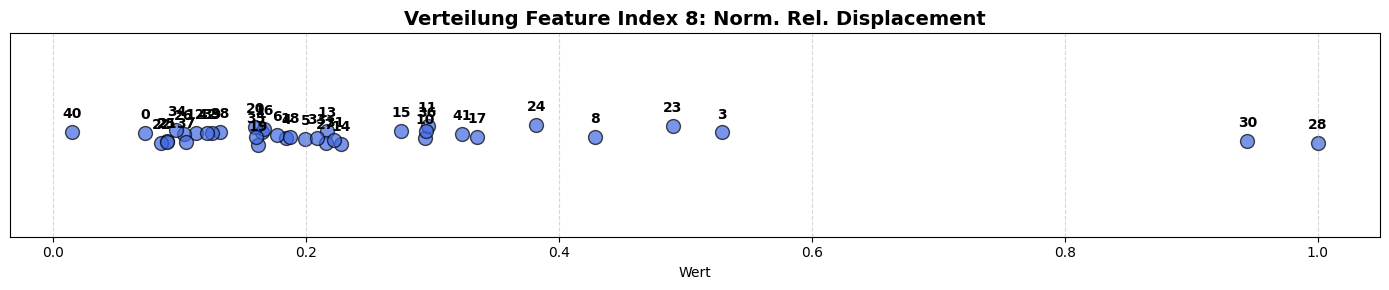

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_univariate_features(X, obj_ids, occurrence_counts, total_frames):
    # 1. Vor-Filterung: Nur stabile Objekte (>= 50% Präsenz)
    stable_indices = [i for i, oid in enumerate(obj_ids) if (occurrence_counts[oid] / total_frames) >= 0.5]
    X_stable = X[stable_indices]
    stable_ids = [obj_ids[i] for i in stable_indices]

    # Feature Namen
    feature_names = [
        "Index 0: Avg Area",
        "Index 1: Std Area",
        "Index 2: Circularity / Solidity / Defects",
        "Index 3: Mean Velocity",
        "Index 4: Max Velocity",
        "Index 5: Relative Area Delta",
        "Index 6: Speed Delta",
        "Index 7: Max Path Distance",
        "Index 8: Norm. Rel. Displacement",
        "Index 9: Roughness" # Falls vorhanden
    ]

    # 2. Loop über alle Features (dynamisch, je nachdem wie viele Spalten X hat)
    num_features = X_stable.shape[1]
    for feat_idx in range(num_features):
        values = X_stable[:, feat_idx]
        
        # --- NEU: Print-Ausgabe speziell für Index 2 ---
        if feat_idx == 2:
            print("\n" + "="*30)
            print(f"WERTE FÜR {feature_names[feat_idx]}")
            print("="*30)
            # Wir erstellen Paare aus (ID, Wert) und sortieren sie nach dem Wert
            id_value_pairs = sorted(zip(stable_ids, values), key=lambda x: x[1])
            for oid, val in id_value_pairs:
                print(f"ID {oid:3d} : {val:.4f}")
            print("="*30 + "\n")

        # --- Plot-Logik (bleibt wie gewünscht) ---
        plt.figure(figsize=(14, 3))
        jitter = np.random.uniform(-0.1, 0.1, size=len(values))
        plt.scatter(values, jitter, c='royalblue', s=100, edgecolors='black', alpha=0.7)

        for i, obj_id in enumerate(stable_ids):
            plt.annotate(
                obj_id, 
                (values[i], jitter[i]),
                xytext=(0, 10), 
                textcoords="offset points", 
                ha='center', 
                fontsize=10, 
                fontweight='bold'
            )

        plt.title(f"Verteilung Feature {feature_names[feat_idx] if feat_idx < len(feature_names) else feat_idx}", fontsize=14, fontweight='bold')
        plt.xlabel("Wert")
        plt.yticks([]) 
        plt.ylim(-1, 1)
        plt.grid(True, axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# Aufruf
plot_univariate_features(X, obj_ids, occurrence_counts, total_frames)

## Nächster Ansatz

In [18]:
# ... (nach extract_features)

snail_ids = []
fish_ids = []

for obj_id, features in results.items():
    # Hier wird die ID in einen normalen Python-Int umgewandelt
    obj_id = int(obj_id)
    
    rep_defects = features[2]
    max_path_dist = features[7]
    
    # Lebensdauer-Check (occurrence_counts muss auch int-Keys nutzen)
    persistence = occurrence_counts[obj_id] / total_frames
    
    if persistence < 0.6:
        fish_ids.append(obj_id)
        continue

    # Filter-Logik
    if max_path_dist < 100 and rep_defects == 0:
        snail_ids.append(obj_id)
    else:
        fish_ids.append(obj_id)

# Jetzt ist die Ausgabe sauber:
print(f"Als Schnecke identifiziert: {snail_ids}")

Als Schnecke identifiziert: [22, 37]


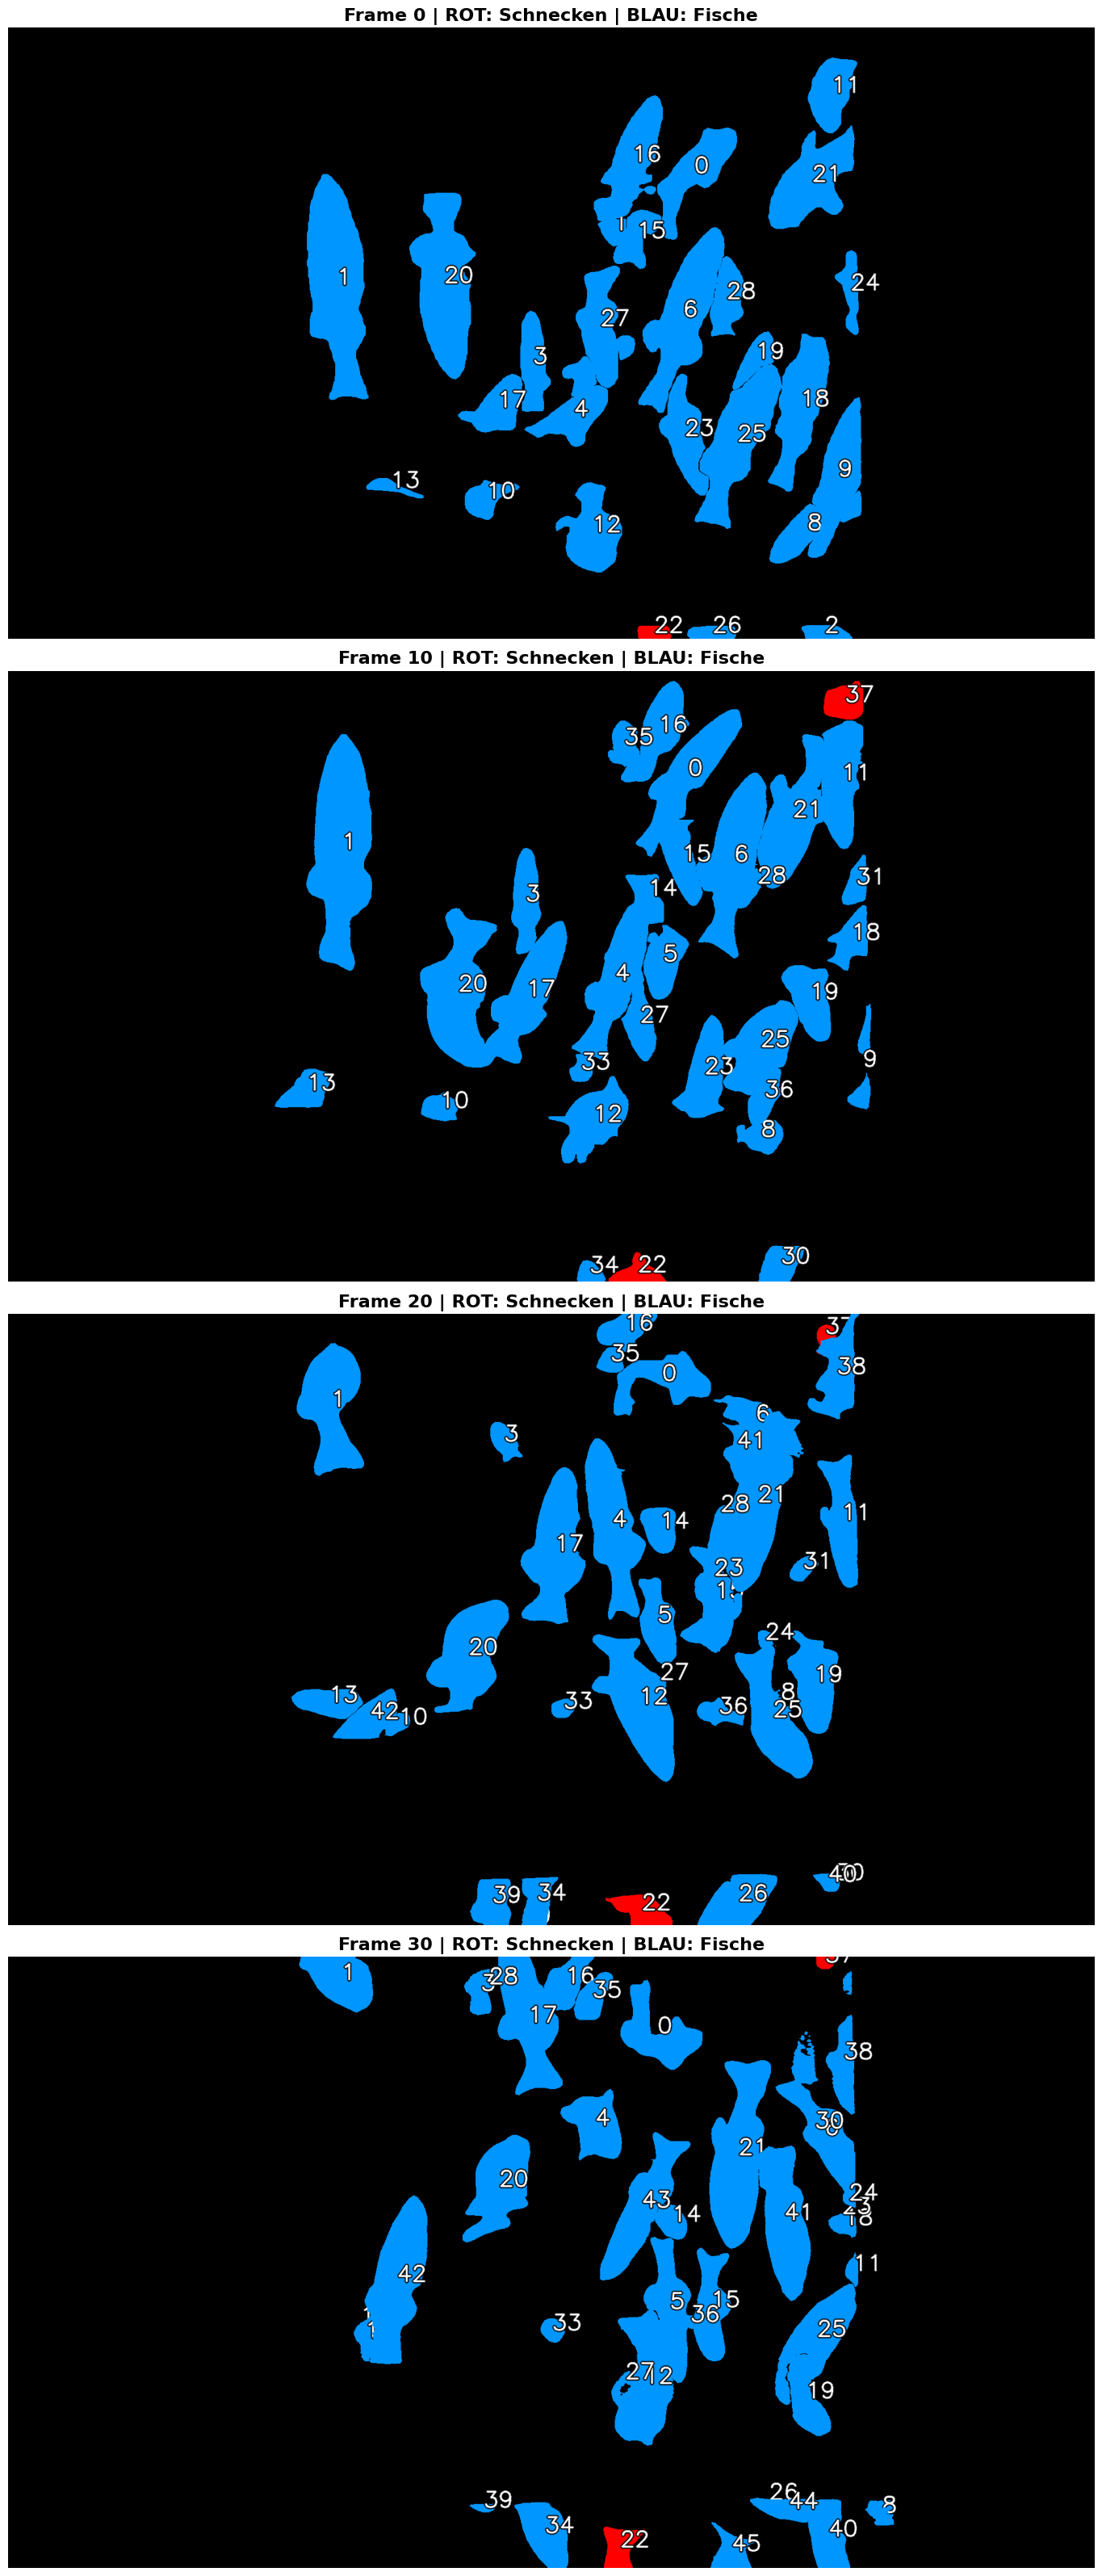

In [19]:
plot_snails_vs_fish(loaded_data, snail_ids, step=10)